# Tech Challenge - Extra CNN Mamografia

Este notebook contém somente a versão final do módulo extra de visão computacional do projeto.

**Modelo final selecionado:** DenseNet121 com Transfer Learning  
**Entrada:** mamografias redimensionadas para `320x320`  
**Threshold final:** `0.38`  
**Objetivo:** classificar imagens de mamografia como **Benigno** ou **Maligno**.

## Resultado final obtido no conjunto de teste

| Métrica | Resultado |
|---|---:|
| Accuracy | 67,16% |
| Precision maligno | 56,66% |
| Recall maligno | 83,56% |
| F1-score maligno | 67,53% |
| ROC-AUC | 76,77% |

A escolha do modelo final priorizou o **recall da classe maligna**, pois, em um contexto de triagem médica, é mais crítico deixar passar um caso maligno do que gerar um falso alerta.

## Bloco 1 — Configuração do ambiente

Este bloco instala/importa as bibliotecas principais, monta o Google Drive e define os caminhos usados no projeto.

> Execute este bloco primeiro. Ele não treina modelo, apenas prepara o ambiente.

In [8]:
# ============================================================
# BLOCO 1 - Configuração do ambiente
# ============================================================

!pip install -q tensorflow scikit-learn matplotlib seaborn opencv-python

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

drive.mount('/content/drive')

# Caminhos principais do projeto no Google Drive
BASE_DIR = "/content/drive/MyDrive/tech_challenge_cbis_ddsm"
PROJECT_DIR = "/content/drive/MyDrive/tech_challenge_cnn_mamografia"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")
SPLITS_DIR = os.path.join(PROJECT_DIR, "splits")

os.makedirs(REPORT_DIR, exist_ok=True)

# Modelo final escolhido
MODEL_FINAL_PATH = os.path.join(MODEL_DIR, "best_densenet121_320.keras")

# Configuração final do modelo
IMG_SIZE = (320, 320)
BATCH_SIZE = 8
THRESHOLD_FINAL = 0.38

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))
print("Dataset existe:", os.path.exists(BASE_DIR))
print("Modelo final existe:", os.path.exists(MODEL_FINAL_PATH))
print("Caminho do modelo final:", MODEL_FINAL_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
GPU disponível: []
Dataset existe: True
Modelo final existe: True
Caminho do modelo final: /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_densenet121_320.keras


## Bloco 2 — Carregamento dos dados de teste

Este bloco carrega os arquivos `train_df.csv`, `val_df.csv` e `test_df.csv` já preparados anteriormente.

Para a avaliação final, usamos principalmente o `test_df.csv`, que representa o conjunto de teste separado e não usado no treinamento.

In [9]:
# ============================================================
# BLOCO 2 - Carregar splits salvos e reparar caminhos das imagens
# ============================================================

import os
import glob
import pandas as pd

SPLITS_DIR = os.path.join(PROJECT_DIR, "splits")

train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train_df.csv"))
val_df = pd.read_csv(os.path.join(SPLITS_DIR, "val_df.csv"))
test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test_df.csv"))

print("Splits carregados:")
print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

# ------------------------------------------------------------
# Função para tentar corrigir caminhos quebrados
# ------------------------------------------------------------

def construir_indice_imagens(base_dir):
    print("\nCriando índice de imagens disponíveis no dataset...")

    imagens = (
        glob.glob(os.path.join(base_dir, "jpeg", "**", "*.jpg"), recursive=True) +
        glob.glob(os.path.join(base_dir, "jpeg", "**", "*.jpeg"), recursive=True) +
        glob.glob(os.path.join(base_dir, "jpeg", "**", "*.png"), recursive=True)
    )

    indice = {}

    for caminho in imagens:
        nome_arquivo = os.path.basename(caminho)
        pasta_pai = os.path.basename(os.path.dirname(caminho))

        # Chave 1: pasta/arquivo
        chave_1 = f"{pasta_pai}/{nome_arquivo}"
        indice[chave_1] = caminho

        # Chave 2: somente nome do arquivo, fallback
        if nome_arquivo not in indice:
            indice[nome_arquivo] = caminho

    print("Total de imagens indexadas:", len(imagens))
    return indice

indice_imagens = construir_indice_imagens(BASE_DIR)

def reparar_caminho(caminho):
    caminho = str(caminho)

    # Se já existe, mantém
    if os.path.exists(caminho):
        return caminho

    # Tenta reparar caso o prefixo esteja diferente
    if "/jpeg/" in caminho:
        sufixo = caminho.split("/jpeg/")[-1]
        candidato = os.path.join(BASE_DIR, "jpeg", sufixo)

        if os.path.exists(candidato):
            return candidato

        partes = sufixo.split("/")

        # tenta pasta/arquivo
        if len(partes) >= 2:
            chave = "/".join(partes[-2:])
            if chave in indice_imagens:
                return indice_imagens[chave]

        # tenta só arquivo
        nome_arquivo = partes[-1]
        if nome_arquivo in indice_imagens:
            return indice_imagens[nome_arquivo]

    # fallback: tenta só pelo nome do arquivo
    nome_arquivo = os.path.basename(caminho)
    if nome_arquivo in indice_imagens:
        return indice_imagens[nome_arquivo]

    return None

# Cria coluna final corrigida
train_df["image_path_final"] = train_df["image_path_local"].apply(reparar_caminho)
val_df["image_path_final"] = val_df["image_path_local"].apply(reparar_caminho)
test_df["image_path_final"] = test_df["image_path_local"].apply(reparar_caminho)

print("\nValidação final dos caminhos das imagens:")
print("Treino:", train_df["image_path_final"].apply(lambda x: os.path.exists(str(x))).sum(), "de", len(train_df))
print("Validação:", val_df["image_path_final"].apply(lambda x: os.path.exists(str(x))).sum(), "de", len(val_df))
print("Teste:", test_df["image_path_final"].apply(lambda x: os.path.exists(str(x))).sum(), "de", len(test_df))

# Remove registros que ainda ficaram sem imagem, se houver
train_df = train_df[train_df["image_path_final"].apply(lambda x: os.path.exists(str(x)))].copy()
val_df = val_df[val_df["image_path_final"].apply(lambda x: os.path.exists(str(x)))].copy()
test_df = test_df[test_df["image_path_final"].apply(lambda x: os.path.exists(str(x)))].copy()

print("\nApós validação:")
print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

display(test_df.head())

Splits carregados:
Treino: (2497, 6)
Validação: (535, 6)
Teste: (536, 6)

Criando índice de imagens disponíveis no dataset...
Total de imagens indexadas: 10237

Validação final dos caminhos das imagens:
Treino: 2497 de 2497
Validação: 535 de 535
Teste: 536 de 536

Após validação:
Treino: (2497, 7)
Validação: (535, 7)
Teste: (536, 7)


,patient_id,pathology,target,tipo_lesao,origem_base,image_path_local,image_path_final
0,P_00539,MALIGNANT,1,calcificacao,train,/content/drive/MyDrive/tech_challenge_cbis_dds...,/content/drive/MyDrive/tech_challenge_cbis_dds...
1,P_00392,MALIGNANT,1,calcificacao,train,/content/drive/MyDrive/tech_challenge_cbis_dds...,/content/drive/MyDrive/tech_challenge_cbis_dds...
2,P_01184,BENIGN,0,calcificacao,train,/content/drive/MyDrive/tech_challenge_cbis_dds...,/content/drive/MyDrive/tech_challenge_cbis_dds...
3,P_00823,BENIGN,0,massa,train,/content/drive/MyDrive/tech_challenge_cbis_dds...,/content/drive/MyDrive/tech_challenge_cbis_dds...
4,P_00353,MALIGNANT,1,calcificacao,test,/content/drive/MyDrive/tech_challenge_cbis_dds...,/content/drive/MyDrive/tech_challenge_cbis_dds...


## Bloco 3 — Pipeline de imagens para DenseNet121

Este bloco cria o pipeline de leitura das imagens do conjunto de teste.

Ponto importante: a DenseNet121 exige o pré-processamento específico `densenet_preprocess`. Sem esse pré-processamento, as métricas ficam incorretas.

In [10]:
# ============================================================
# BLOCO 3 - Pipeline de imagens com preprocess correto da DenseNet
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

def carregar_imagem_densenet(path, label):
    imagem = tf.io.read_file(path)
    imagem = tf.image.decode_image(imagem, channels=3, expand_animations=False)
    imagem.set_shape([None, None, 3])
    imagem = tf.image.resize(imagem, IMG_SIZE)
    imagem = tf.cast(imagem, tf.float32)

    # Pré-processamento específico da DenseNet121
    imagem = densenet_preprocess(imagem)

    label = tf.cast(label, tf.float32)
    return imagem, label


def criar_dataset_densenet(dataframe, shuffle=False):
    caminhos = dataframe["image_path_local"].astype(str).values
    labels = dataframe["target"].astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices((caminhos, labels))
    ds = ds.map(carregar_imagem_densenet, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


test_ds = criar_dataset_densenet(test_df, shuffle=False)

print("Pipeline do conjunto de teste criado com sucesso.")

for imagens, labels in test_ds.take(1):
    print("Formato das imagens:", imagens.shape)
    print("Formato dos labels:", labels.shape)


Pipeline do conjunto de teste criado com sucesso.
Formato das imagens: (8, 320, 320, 3)
Formato dos labels: (8,)


## Bloco 4 — Carregamento do modelo final

Este bloco carrega o modelo final salvo no Google Drive: `best_densenet121_320.keras`.

Este notebook **não treina novamente** o modelo. Ele apenas carrega o melhor modelo já treinado e reproduz a avaliação final.

In [11]:
# ============================================================
# BLOCO 4 - Carregar modelo final DenseNet121
# ============================================================

if not os.path.exists(MODEL_FINAL_PATH):
    raise FileNotFoundError(
        "Modelo final não encontrado. Verifique se o arquivo "
        "best_densenet121_320.keras está salvo em PROJECT_DIR/models."
    )

modelo_final = tf.keras.models.load_model(MODEL_FINAL_PATH)

print("Modelo final carregado com sucesso.")
print("Modelo:", MODEL_FINAL_PATH)
print("Threshold final:", THRESHOLD_FINAL)


Modelo final carregado com sucesso.
Modelo: /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_densenet121_320.keras
Threshold final: 0.38


## Bloco 5 — Avaliação final do modelo

Este bloco gera as probabilidades do modelo no conjunto de teste, aplica o threshold final `0.38` e calcula as principais métricas:

- Accuracy
- Precision da classe maligna
- Recall da classe maligna
- F1-score da classe maligna
- ROC-AUC

A classe `1` representa **Maligno** e a classe `0` representa **Benigno**.

In [12]:
# ============================================================
# BLOCO 5 - Avaliação final
# ============================================================

y_true = test_df["target"].values

y_prob = modelo_final.predict(test_ds).ravel()
y_pred = (y_prob >= THRESHOLD_FINAL).astype(int)

acc = accuracy_score(y_true, y_pred)
prec_maligno = precision_score(y_true, y_pred, zero_division=0)
rec_maligno = recall_score(y_true, y_pred, zero_division=0)
f1_maligno = f1_score(y_true, y_pred, zero_division=0)
auc_final = roc_auc_score(y_true, y_prob)

print("Resultado final - DenseNet121")
print("Threshold:", THRESHOLD_FINAL)
print()
print(f"Accuracy:          {acc:.4f}")
print(f"Precision maligno: {prec_maligno:.4f}")
print(f"Recall maligno:    {rec_maligno:.4f}")
print(f"F1 maligno:        {f1_maligno:.4f}")
print(f"ROC-AUC:           {auc_final:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Benigno", "Maligno"]
))

# Salva as probabilidades e predições finais
resultado_final = pd.DataFrame({
    "y_true": y_true,
    "y_prob_maligno": y_prob,
    "y_pred": y_pred
})

resultado_path = os.path.join(REPORT_DIR, "resultado_final_densenet121.csv")
resultado_final.to_csv(resultado_path, index=False)

print("\nResultado final salvo em:", resultado_path)


67/67 ━━━━━━━━━━━━━━━━━━━━ 290s 4s/step
Resultado final - DenseNet121
Threshold: 0.38

Accuracy:          0.6716
Precision maligno: 0.5666
Recall maligno:    0.8356
F1 maligno:        0.6753
ROC-AUC:           0.7678

Classification Report:
              precision    recall  f1-score   support

     Benigno       0.83      0.56      0.67       317
     Maligno       0.57      0.84      0.68       219

    accuracy                           0.67       536
   macro avg       0.70      0.70      0.67       536
weighted avg       0.72      0.67      0.67       536


Resultado final salvo em: /content/drive/MyDrive/tech_challenge_cnn_mamografia/reports/resultado_final_densenet121.csv


## Bloco 6 — Matriz de confusão

A matriz de confusão mostra os acertos e erros do modelo para cada classe.

No contexto médico, o ponto mais crítico é o **falso negativo**, ou seja, casos malignos classificados incorretamente como benignos.

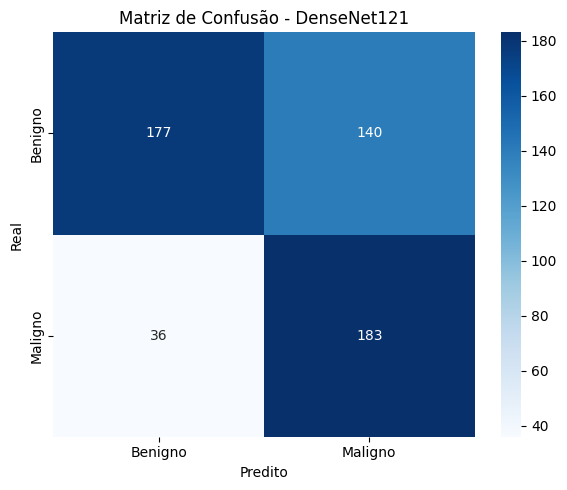

Matriz de confusão salva em: /content/drive/MyDrive/tech_challenge_cnn_mamografia/reports/matriz_confusao_densenet121.png

Matriz numérica:
[[177 140]
 [ 36 183]]


In [13]:
# ============================================================
# BLOCO 6 - Matriz de confusão
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)
plt.title("Matriz de Confusão - DenseNet121")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()

matriz_path = os.path.join(REPORT_DIR, "matriz_confusao_densenet121.png")
plt.savefig(matriz_path, dpi=300, bbox_inches="tight")
plt.show()

print("Matriz de confusão salva em:", matriz_path)
print("\nMatriz numérica:")
print(cm)


## Bloco 7 — Curva ROC

A curva ROC avalia a capacidade do modelo de separar as classes Benigno e Maligno em diferentes thresholds.

O valor de ROC-AUC obtido foi aproximadamente **0,7677**, indicando uma capacidade razoável de distinção entre as classes.

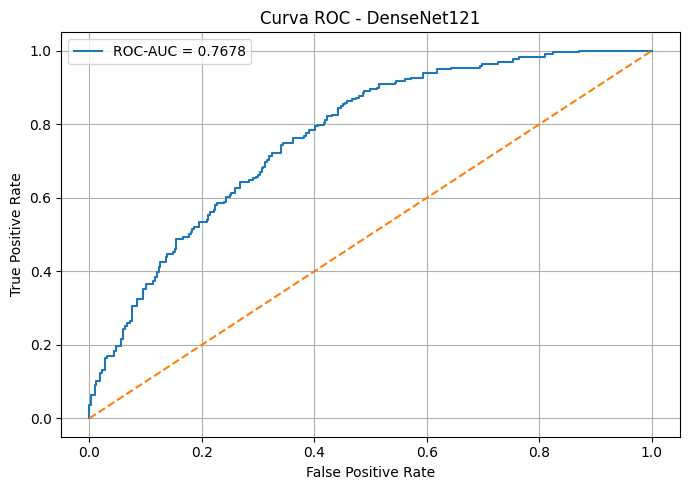

Curva ROC salva em: /content/drive/MyDrive/tech_challenge_cnn_mamografia/reports/curva_roc_densenet121.png


In [14]:
# ============================================================
# BLOCO 7 - Curva ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_final = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_final:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC - DenseNet121")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()

roc_path = os.path.join(REPORT_DIR, "curva_roc_densenet121.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Curva ROC salva em:", roc_path)


## Bloco 8 — Tabela final de métricas

Este bloco consolida as métricas finais em uma tabela e salva o arquivo em CSV para uso no relatório.

In [15]:
# ============================================================
# BLOCO 8 - Tabela final de métricas
# ============================================================

metricas_finais = pd.DataFrame([{
    "modelo": "DenseNet121_320x320_threshold_0.38",
    "threshold": THRESHOLD_FINAL,
    "accuracy": acc,
    "precision_maligno": prec_maligno,
    "recall_maligno": rec_maligno,
    "f1_maligno": f1_maligno,
    "roc_auc": auc_final
}])

display(metricas_finais)

metricas_path = os.path.join(REPORT_DIR, "metricas_finais_densenet121.csv")
metricas_finais.to_csv(metricas_path, index=False)

print("Métricas finais salvas em:", metricas_path)


,modelo,threshold,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc
0,DenseNet121_320x320_threshold_0.38,0.38,0.671642,0.566563,0.835616,0.675277,0.767757


Métricas finais salvas em: /content/drive/MyDrive/tech_challenge_cnn_mamografia/reports/metricas_finais_densenet121.csv


## Bloco 9 — Interpretação final do modelo CNN

O modelo final selecionado para a etapa extra de visão computacional foi uma CNN baseada na arquitetura **DenseNet121**, utilizando **Transfer Learning** e imagens de mamografia redimensionadas para **320x320 pixels**.

Após os experimentos com diferentes arquiteturas, incluindo EfficientNetB0, DenseNet121, Xception, ensemble e pré-processamento com CLAHE, a melhor configuração clínica foi obtida com o modelo **DenseNet121 sem CLAHE**, utilizando threshold ajustado para **0.38**.

No conjunto de teste, o modelo apresentou os seguintes resultados:

- **Accuracy:** 67,16%
- **Precision da classe maligna:** 56,66%
- **Recall da classe maligna:** 83,56%
- **F1-score da classe maligna:** 67,53%
- **ROC-AUC:** 76,77%

A matriz de confusão indicou que, dos **219 casos malignos** presentes no conjunto de teste, o modelo identificou corretamente **183 casos**, deixando **36 falsos negativos**. Esse resultado demonstra boa sensibilidade para a classe maligna, característica importante em problemas de triagem médica.

Embora o modelo Xception tenha apresentado maior acurácia geral, o DenseNet121 foi considerado mais adequado para o contexto do projeto, pois apresentou maior capacidade de identificar casos malignos. Em aplicações de apoio ao diagnóstico, reduzir falsos negativos é mais relevante do que maximizar apenas a acurácia geral.

Dessa forma, o modelo desenvolvido deve ser interpretado como uma ferramenta complementar de apoio à triagem médica, e não como substituto do diagnóstico médico. A decisão final deve permanecer sob responsabilidade de profissionais de saúde.

## Observação final

Este notebook foi limpo para manter apenas a avaliação do **melhor resultado final**. Os experimentos descartados, como EfficientNetB0, Xception, ensemble e CLAHE, não foram mantidos neste arquivo para evitar confusão na entrega final.

Para reproduzir os gráficos e arquivos finais, execute os blocos em ordem, do Bloco 1 ao Bloco 9.